In [29]:
from kan import KAN, LBFGS, MLP
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm
import math
import numpy as np

device = torch.device('cpu')
print(device)

cpu


In [30]:
def sol_fun(x, dim, data):
    if data=='A':
        return torch.exp(1/dim * torch.sum(torch.sin(torch.pi * x / 2) ** 2, dim=1, keepdim=True))
    elif data=='B':
        # x_safe = x.clone()
        # x_safe[x_safe == 0.0] = 1.0
        # g_x = torch.exp(-1.0 / (x_safe ** 2))
        # g_x = torch.where(x == 0.0, torch.zeros_like(x), g_x)
        # return torch.sum(g_x, dim=1, keepdim=True)
        inside_mask = (x > -1.0) & (x < 1.0)
        safe_x = torch.where(inside_mask, x, torch.zeros_like(x))
        bump = torch.exp(1.0 / (safe_x ** 2 - 1.0))
        bump_masked = torch.where(inside_mask, bump, torch.zeros_like(bump))
        return torch.sum(bump_masked, dim=1, keepdim=True)
    elif data=='C':
        return 1/math.sqrt(dim) * torch.sum(x, dim=1, keepdim=True)
    else:
        raise ValueError("Invalid data type. Choose from 'A', 'B', or 'C'.")

In [31]:
ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 1200
grids = [3, 5, 10, 20, 50, 100]
k=5
lr=1
dimensions = [1000, 500, 200, 100, 50, 20, 10, 5]
# dimensions = [1000]

In [32]:
def generate_dataset(dim, data, n_train=None, n_test=None, seed=1):
    if n_train is None:
        n_train = globals().get('n_train', 1000)
    if n_test is None:
        n_test = globals().get('n_test', 200)
    
    torch.manual_seed(seed)
    
    x_train = torch.rand((n_train, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_train = sol_fun(x_train, dim, data)
    x_test = torch.rand((n_test, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_test = sol_fun(x_test, dim, data)
    dataset = {
        'train_input': x_train,
        'train_label': y_train,
        'test_input': x_test,
        'test_label': y_test
    }
    return dataset

In [33]:
def train_kan(width, dataset, static=True, seed=1):
    
    rmses = []
    r2s = []
    if not static:
        run_steps = steps // len(grids)
    else:
        run_steps = steps

    for grid in grids:
        if grid == grids[0]:
            model = KAN(width=width, grid=grid, k=3, seed=seed, device=device, auto_save=False)
            model = model.speed()
        else:
            model.save_act = True
            model.get_act(dataset['train_input'])
            model = model.refine(grid)
            model = model.speed()
        criterion = torch.nn.MSELoss()

        optimizer = LBFGS(
                model.parameters(), 
                lr=lr, 
                history_size=10, 
                line_search_fn="strong_wolfe",
                tolerance_grad=1e-32, 
                tolerance_change=1e-32, 
                tolerance_ys=1e-32
            )
        pbar = tqdm(range(run_steps), desc='description', ncols=100)

        for _ in pbar:
            def closure():
                optimizer.zero_grad()
                loss = criterion(model(dataset['train_input']), dataset['train_label'])
                loss.backward()
                return loss

            if _ % 10 == 0 and _ < 50:
                model.update_grid_from_samples(dataset['train_input'])

            optimizer.step(closure)
            with torch.no_grad():
                test_pred = model(dataset['test_input'])
                mse = criterion(test_pred, dataset['test_label'])
                rmse = torch.sqrt(mse).item()
                r2 = r2_score(dataset['test_label'].cpu().numpy(), test_pred.cpu().numpy())

            pbar.set_description("rmse: %.2e | r2: %.2e " % (rmse, r2))

            rmses.append(rmse)
            r2s.append(r2)
        if static:
            break
    
    with torch.no_grad():
        final_pred = model(dataset['test_input'])
            
    results = {
        "rmses": rmses,
        "r2s": r2s,
        "preds": final_pred
    }
    return results

In [34]:
def train_mlp(width, dataset, seed=1):
    
    def r2s():
        with torch.no_grad():
            pred = mlp_model(dataset['test_input'].to(mlp_model.device))
        target = dataset['test_label'].to(mlp_model.device)
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    torch.manual_seed(seed)
    mlp_model = MLP.MLP(width=width, act='silu', device='cpu')
    mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
    results = mlp_model.fit(dataset, opt="LBFGS", steps=steps, lr=lr, metrics=[r2s])
    results['param_counts'] = mlp_params

    with torch.no_grad():
        final_pred = mlp_model(dataset['test_input'].to(mlp_model.device))
    results['preds'] = final_pred
    
    return results

In [35]:
# seeds = [0, 1, 42]
seeds = [0]


def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset = generate_dataset(dim=d, seed=seed, data=data)
            torch.save(dataset, f'{data}_dataset_dim{d}_seed{seed}.pt')
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = (kan_param - 1) // (width[0] + 2)
            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
    torch.save(static_kan, f'static_kan_{data}.pt')
    torch.save(dyn_kan, f'dyn_{data}.pt')
    torch.save(mlp, f'mlp_{data}.pt')
    return static_kan, dyn_kan, mlp


In [36]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

rmse: 7.94e-02 | r2: -1.92e+01 : 100%|██████████████████████████| 1200/1200 [35:54<00:00,  1.80s/it]
rmse: 8.71e-02 | r2: -2.34e+01 : 100%|████████████████████████████| 200/200 [13:26<00:00,  4.03s/it]
rmse: 1.23e-01 | r2: -4.75e+01 : 100%|████████████████████████████| 200/200 [08:57<00:00,  2.69s/it]
rmse: 1.99e-01 | r2: -1.27e+02 : 100%|████████████████████████████| 200/200 [06:54<00:00,  2.07s/it]
rmse: 2.77e-01 | r2: -2.46e+02 : 100%|████████████████████████████| 200/200 [08:32<00:00,  2.56s/it]
rmse: 3.23e-01 | r2: -3.35e+02 : 100%|████████████████████████████| 200/200 [12:40<00:00,  3.80s/it]
rmse: 3.43e-01 | r2: -3.76e+02 : 100%|████████████████████████████| 200/200 [28:52<00:00,  8.66s/it]
| train_loss: 2.12e-04 | test_loss: 2.53e-02 | reg: 8.18e+02 | : 100%|█| 1200/1200 [01:40<00:00, 11.


Dimension 1000: KAN params: 11013, MLP params: 10021


rmse: 9.74e-02 | r2: -1.34e+01 : 100%|██████████████████████████| 1200/1200 [36:43<00:00,  1.84s/it]
rmse: 9.74e-02 | r2: -1.34e+01 : 100%|████████████████████████████| 200/200 [17:20<00:00,  5.20s/it]
rmse: 1.69e-01 | r2: -4.22e+01 : 100%|████████████████████████████| 200/200 [05:37<00:00,  1.69s/it]
rmse: 3.16e-01 | r2: -1.50e+02 : 100%|████████████████████████████| 200/200 [05:18<00:00,  1.59s/it]
rmse: 4.42e-01 | r2: -2.95e+02 : 100%|████████████████████████████| 200/200 [05:33<00:00,  1.67s/it]
rmse: 5.23e-01 | r2: -4.13e+02 : 100%|████████████████████████████| 200/200 [08:37<00:00,  2.59s/it]
rmse: 5.49e-01 | r2: -4.55e+02 : 100%|████████████████████████████| 200/200 [14:57<00:00,  4.49s/it]
| train_loss: 2.81e-04 | test_loss: 3.78e-02 | reg: 8.08e+02 | : 100%|█| 1200/1200 [01:18<00:00, 15.


Dimension 500: KAN params: 5513, MLP params: 5021


rmse: 5.56e-01 | r2: -1.98e+02 : 100%|██████████████████████████| 1200/1200 [44:42<00:00,  2.24s/it]
rmse: 3.97e-01 | r2: -1.00e+02 : 100%|████████████████████████████| 200/200 [07:14<00:00,  2.17s/it]
rmse: 2.96e-01 | r2: -5.55e+01 : 100%|████████████████████████████| 200/200 [06:59<00:00,  2.10s/it]
rmse: 3.19e-01 | r2: -6.47e+01 : 100%|████████████████████████████| 200/200 [05:07<00:00,  1.54s/it]
rmse: 4.12e-01 | r2: -1.08e+02 : 100%|████████████████████████████| 200/200 [02:58<00:00,  1.12it/s]
rmse: 5.05e-01 | r2: -1.63e+02 : 100%|████████████████████████████| 200/200 [05:21<00:00,  1.61s/it]
rmse: 5.35e-01 | r2: -1.83e+02 : 100%|████████████████████████████| 200/200 [06:14<00:00,  1.87s/it]
| train_loss: 2.88e-06 | test_loss: 5.97e-02 | reg: 2.49e+02 | : 100%|█| 1200/1200 [01:04<00:00, 18.


...

Dimension 20: KAN params: 233, MLP params: 221


rmse: 6.29e-03 | r2: 9.99e-01 : 100%|███████████████████████████| 1200/1200 [02:49<00:00,  7.06it/s]
rmse: 6.29e-03 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [00:35<00:00,  5.59it/s]
rmse: 5.70e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:41<00:00,  4.85it/s]
rmse: 3.89e-05 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:37<00:00,  5.36it/s]
rmse: 7.51e-06 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:37<00:00,  5.31it/s]
rmse: 2.71e-06 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:42<00:00,  4.72it/s]
rmse: 2.76e-06 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:41<00:00,  4.81it/s]
| train_loss: 5.79e-02 | test_loss: 6.76e-02 | reg: 7.58e+01 | : 100%|█| 1200/1200 [01:05<00:00, 18.


Dimension 10: KAN params: 123, MLP params: 121


rmse: 9.06e-03 | r2: 9.99e-01 : 100%|███████████████████████████| 1200/1200 [02:32<00:00,  7.86it/s]
rmse: 9.06e-03 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [00:34<00:00,  5.74it/s]
rmse: 9.09e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:36<00:00,  5.55it/s]
rmse: 3.58e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:36<00:00,  5.43it/s]
rmse: 2.56e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:32<00:00,  6.24it/s]
rmse: 3.54e-02 | r2: 9.82e-01 : 100%|█████████████████████████████| 200/200 [00:36<00:00,  5.41it/s]
rmse: 8.28e-02 | r2: 9.01e-01 : 100%|█████████████████████████████| 200/200 [00:46<00:00,  4.32it/s]
| train_loss: 2.75e-02 | test_loss: 3.39e-02 | reg: 5.48e+01 | : 100%|█| 1200/1200 [01:08<00:00, 17.


Dimension 5: KAN params: 68, MLP params: 64


In [37]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

rmse: 1.15e+00 | r2: -2.89e+00 : 100%|██████████████████████████| 1200/1200 [40:47<00:00,  2.04s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [10:15<00:00,  3.08s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [06:44<00:00,  2.02s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [05:44<00:00,  1.72s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [07:54<00:00,  2.37s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [12:21<00:00,  3.71s/it]
rmse: 1.16e+00 | r2: -2.98e+00 : 100%|████████████████████████████| 200/200 [23:28<00:00,  7.04s/it]
| train_loss: 5.87e-08 | test_loss: 2.78e-01 | reg: 2.60e+02 | : 100%|█| 1200/1200 [01:22<00:00, 14.


Dimension 1000: KAN params: 11013, MLP params: 10021


rmse: 1.79e-01 | r2: 9.07e-01 : 100%|███████████████████████████| 1200/1200 [27:14<00:00,  1.36s/it]
rmse: 1.81e-01 | r2: 9.05e-01 : 100%|█████████████████████████████| 200/200 [07:30<00:00,  2.25s/it]
rmse: 1.81e-01 | r2: 9.05e-01 : 100%|█████████████████████████████| 200/200 [04:25<00:00,  1.33s/it]
rmse: 1.81e-01 | r2: 9.05e-01 : 100%|█████████████████████████████| 200/200 [03:31<00:00,  1.06s/it]
rmse: 1.81e-01 | r2: 9.05e-01 : 100%|█████████████████████████████| 200/200 [05:17<00:00,  1.59s/it]
rmse: 1.85e-01 | r2: 9.01e-01 : 100%|█████████████████████████████| 200/200 [09:17<00:00,  2.79s/it]
rmse: 2.02e-01 | r2: 8.81e-01 : 100%|█████████████████████████████| 200/200 [13:19<00:00,  4.00s/it]
| train_loss: 1.25e-07 | test_loss: 1.05e-01 | reg: 2.36e+02 | : 100%|█| 1200/1200 [01:05<00:00, 18.


Dimension 500: KAN params: 5513, MLP params: 5021


rmse: 1.18e-02 | r2: 1.00e+00 : 100%|███████████████████████████| 1200/1200 [20:05<00:00,  1.00s/it]
rmse: 1.39e-02 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [06:15<00:00,  1.88s/it]
rmse: 1.28e-02 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [04:36<00:00,  1.38s/it]
rmse: 1.28e-02 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [02:31<00:00,  1.32it/s]
rmse: 1.28e-02 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [02:31<00:00,  1.32it/s]
rmse: 1.28e-02 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [04:16<00:00,  1.28s/it]
rmse: 1.28e-02 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [05:06<00:00,  1.53s/it]
| train_loss: 1.17e-05 | test_loss: 1.40e-03 | reg: 1.43e+02 | : 100%|█| 1200/1200 [01:18<00:00, 15.


...

Dimension 20: KAN params: 233, MLP params: 221


rmse: 2.77e-04 | r2: 1.00e+00 : 100%|███████████████████████████| 1200/1200 [03:18<00:00,  6.04it/s]
rmse: 3.24e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:54<00:00,  3.70it/s]
rmse: 6.40e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:38<00:00,  5.13it/s]
rmse: 3.87e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:30<00:00,  6.56it/s]
rmse: 2.44e-02 | r2: 9.98e-01 : 100%|█████████████████████████████| 200/200 [00:26<00:00,  7.68it/s]
rmse: 7.19e-02 | r2: 9.83e-01 : 100%|█████████████████████████████| 200/200 [00:36<00:00,  5.51it/s]
rmse: 9.17e-02 | r2: 9.73e-01 : 100%|█████████████████████████████| 200/200 [00:47<00:00,  4.23it/s]
| train_loss: 2.31e-05 | test_loss: 2.79e-05 | reg: 3.56e+01 | : 100%|█| 1200/1200 [00:56<00:00, 21.


Dimension 10: KAN params: 123, MLP params: 121


rmse: 7.32e-04 | r2: 1.00e+00 : 100%|███████████████████████████| 1200/1200 [02:33<00:00,  7.82it/s]
rmse: 8.23e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:45<00:00,  4.44it/s]
rmse: 2.87e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:30<00:00,  6.47it/s]
rmse: 1.78e-02 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [00:23<00:00,  8.38it/s]
rmse: 6.08e-02 | r2: 9.89e-01 : 100%|█████████████████████████████| 200/200 [00:23<00:00,  8.68it/s]
rmse: 6.47e-02 | r2: 9.88e-01 : 100%|█████████████████████████████| 200/200 [00:37<00:00,  5.37it/s]
rmse: 6.47e-02 | r2: 9.88e-01 : 100%|█████████████████████████████| 200/200 [00:30<00:00,  6.59it/s]
| train_loss: 4.98e-05 | test_loss: 5.71e-05 | reg: 2.61e+01 | : 100%|█| 1200/1200 [01:01<00:00, 19.


Dimension 5: KAN params: 68, MLP params: 64


In [67]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

description:   0%|                                                         | 0/1200 [00:00<?, ?it/s]

rmse: 3.01e+01 | r2: -5.61e+01 : 100%|██████████████████████████| 1200/1200 [32:13<00:00,  1.61s/it]
rmse: 2.60e+01 | r2: -4.15e+01 : 100%|████████████████████████████| 200/200 [08:22<00:00,  2.51s/it]
rmse: 2.40e+01 | r2: -3.53e+01 : 100%|████████████████████████████| 200/200 [08:23<00:00,  2.52s/it]
rmse: 2.71e+01 | r2: -4.54e+01 : 100%|████████████████████████████| 200/200 [05:05<00:00,  1.53s/it]
rmse: 3.89e+01 | r2: -9.45e+01 : 100%|████████████████████████████| 200/200 [14:52<00:00,  4.46s/it]
rmse: 5.00e+01 | r2: -1.57e+02 : 100%|████████████████████████████| 200/200 [28:11<00:00,  8.46s/it]
rmse: 5.46e+01 | r2: -1.87e+02 : 100%|████████████████████████████| 200/200 [20:56<00:00,  6.28s/it]
| train_loss: 2.51e-05 | test_loss: 1.68e+01 | reg: 7.72e+02 | : 100%|█| 1200/1200 [00:55<00:00, 21.


Dimension 1000: KAN params: 11013, MLP params: 10021


rmse: 1.70e+01 | r2: -3.43e+01 : 100%|██████████████████████████| 1200/1200 [17:34<00:00,  1.14it/s]
rmse: 1.66e+01 | r2: -3.26e+01 : 100%|████████████████████████████| 200/200 [05:59<00:00,  1.80s/it]
rmse: 2.27e+01 | r2: -6.22e+01 : 100%|████████████████████████████| 200/200 [04:58<00:00,  1.49s/it]
rmse: 3.59e+01 | r2: -1.57e+02 : 100%|████████████████████████████| 200/200 [04:07<00:00,  1.24s/it]
rmse: 4.32e+01 | r2: -2.27e+02 : 100%|████████████████████████████| 200/200 [06:24<00:00,  1.92s/it]
rmse: 4.79e+01 | r2: -2.79e+02 : 100%|████████████████████████████| 200/200 [05:03<00:00,  1.52s/it]
rmse: 4.98e+01 | r2: -3.02e+02 : 100%|████████████████████████████| 200/200 [06:53<00:00,  2.07s/it]
| train_loss: 2.09e-05 | test_loss: 7.25e+00 | reg: 7.35e+02 | : 100%|█| 1200/1200 [00:40<00:00, 29.


Dimension 500: KAN params: 5513, MLP params: 5021


...

Dimension 20: KAN params: 233, MLP params: 221


rmse: 3.94e-02 | r2: 9.91e-01 : 100%|███████████████████████████| 1200/1200 [03:01<00:00,  6.63it/s]
rmse: 3.94e-02 | r2: 9.91e-01 : 100%|█████████████████████████████| 200/200 [00:29<00:00,  6.72it/s]
rmse: 1.02e-02 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [00:30<00:00,  6.46it/s]
rmse: 4.83e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:36<00:00,  5.43it/s]
rmse: 5.56e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:46<00:00,  4.26it/s]
rmse: 1.84e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:51<00:00,  3.86it/s]
rmse: 9.89e-05 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:44<00:00,  4.45it/s]
| train_loss: 1.19e-01 | test_loss: 1.61e-01 | reg: 5.95e+01 | : 100%|█| 1200/1200 [00:49<00:00, 24.


Dimension 10: KAN params: 123, MLP params: 121


rmse: 2.81e-02 | r2: 9.91e-01 : 100%|███████████████████████████| 1200/1200 [02:12<00:00,  9.08it/s]
rmse: 2.82e-02 | r2: 9.91e-01 : 100%|█████████████████████████████| 200/200 [00:24<00:00,  8.28it/s]
rmse: 7.55e-03 | r2: 9.99e-01 : 100%|█████████████████████████████| 200/200 [00:24<00:00,  8.32it/s]
rmse: 3.36e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:25<00:00,  7.97it/s]
rmse: 3.69e-04 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:27<00:00,  7.27it/s]
rmse: 2.15e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:28<00:00,  6.94it/s]
rmse: 2.19e-03 | r2: 1.00e+00 : 100%|█████████████████████████████| 200/200 [00:33<00:00,  5.94it/s]
| train_loss: 2.75e-02 | test_loss: 3.14e-02 | reg: 4.83e+01 | : 100%|█| 1200/1200 [00:50<00:00, 23.


Dimension 5: KAN params: 68, MLP params: 64


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = torch.load('static_kan_A.pt', weights_only=False), torch.load('dyn_A.pt', weights_only=False), torch.load('mlp_A.pt', weights_only=False)

In [69]:
def plot_r2s_rmses(static_kan, dyn_kan, mlp):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        lower_errs = []
        upper_errs = []
        
        for d in dimensions:
            final_r2s = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            
            mean_val = np.mean(final_r2s)
            min_val = np.min(final_r2s)
            max_val = np.max(final_r2s)
            
            means.append(mean_val)
            lower_errs.append(mean_val - min_val)
            upper_errs.append(max_val - mean_val)
            
        return np.array(means), np.vstack([lower_errs, upper_errs])

    static_means_r2, static_yerr_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
    dyn_means_r2, dyn_yerr_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
    mlp_means_r2, mlp_yerr_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
    static_means_rmse, static_yerr_rmse = mean_err(static_kan, dimensions, seeds, 'rmses')
    dyn_means_rmse, dyn_yerr_rmse = mean_err(dyn_kan, dimensions, seeds, 'rmses')
    mlp_means_rmse, mlp_yerr_rmse = mean_err(mlp, dimensions, seeds, 'test_loss')

    ax1.errorbar(dimensions, static_means_r2, yerr=static_yerr_r2, marker='s', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='Static KAN G=5')  
    ax1.errorbar(dimensions, dyn_means_r2, yerr=dyn_yerr_r2, marker='^', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='Dynamic KAN G=[3, 5, 10, 20, 50, 100]')    
    ax1.errorbar(dimensions, mlp_means_r2, yerr=mlp_yerr_r2, marker='o', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='MLP')

    cutoff=3
    ax2.errorbar(dimensions[cutoff:], static_means_r2[cutoff:], yerr=static_yerr_r2[:, cutoff:], marker='s', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)
    ax2.errorbar(dimensions[cutoff:], dyn_means_r2[cutoff:], yerr=dyn_yerr_r2[:, cutoff:], marker='^', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)
    # ax2.errorbar(dimensions[cutoff:], mlp_means_r2[cutoff:], yerr=mlp_yerr_r2[:, cutoff:], marker='^', linestyle='-',
                # capsize=4, elinewidth=1.5, alpha=0.8)

    ax3.errorbar(dimensions, static_means_rmse, yerr=static_yerr_rmse, marker='s', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8, )   
    ax3.errorbar(dimensions, dyn_means_rmse, yerr=dyn_yerr_rmse, marker='^', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)  
    ax3.errorbar(dimensions, mlp_means_rmse, yerr=mlp_yerr_rmse, marker='o', linestyle='-', label='MLP',
                capsize=4, elinewidth=1.5, alpha=0.8)

    ax1.set_xlabel('dimensions (log)')
    ax1.set_xscale('log')
    ax1.set_ylabel('R2 Score')
    ax1.axvline(x=100, color='red', linestyle='--', alpha=0.7)
    ax1.set_xticks(dimensions)
    ax1.set_xticklabels(dimensions)

    ax2.set_xlabel('dimensions (log)')
    ax2.set_xscale('log')
    ax2.set_ylabel('R2 Score')
    ax2.set_xticks(dimensions[cutoff:])
    ax2.set_xticklabels(dimensions[cutoff:])
    # ax2.get_yaxis().get_major_formatter().set_useOffset(False)

    ax3.set_xlabel('dimensions (log)')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_ylabel('RMSE (log)')

    handles, labels = ax1.get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3)
    plt.suptitle('KAN vs MLP Performance with Increasing Dimensionality (Function A)')
    plt.tight_layout()
    plt.show()

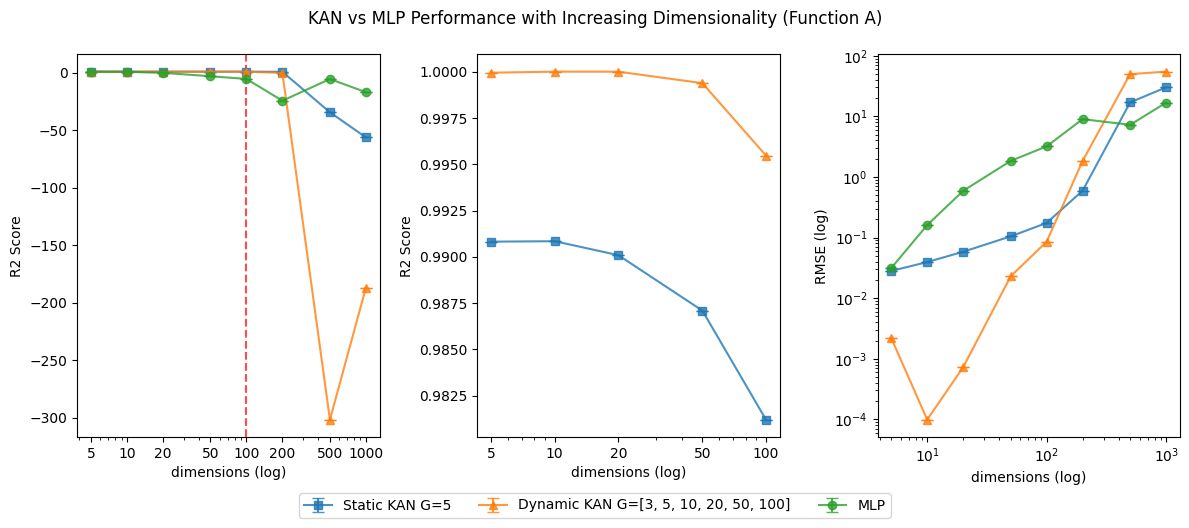

In [70]:
plot_r2s_rmses(static_kan_B, dyn_kan_B, mlp_B)

Text(0.5, 1.0, 'Convergence Curves for Dimension 1000')

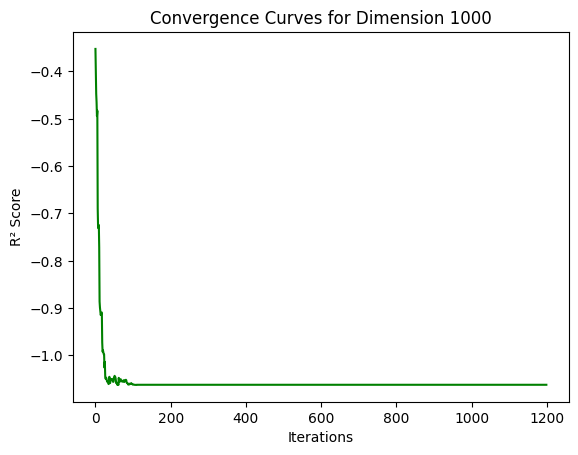

In [43]:
# plt.plot(static_kan_A[0][1000]['rmses'], label='Static KAN')
# plt.plot(dyn_kan_A[0][1000]['rmses'], label='Dynamic KAN')
plt.plot(mlp_A[0][1000]['r2s'], label='MLP', color='green')
plt.xlabel('Iterations')    
plt.ylabel('R² Score')
plt.title('Convergence Curves for Dimension 1000')

C:\Users\runan\AppData\Local\Temp\ipykernel_38904\3656014063.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(loc='upper right', fontsize=10, frameon=True)


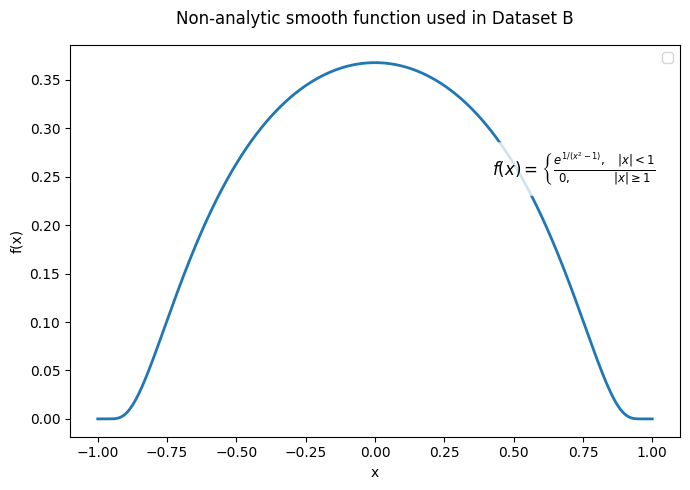

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# x = np.linspace(-1, 1, 1000)
# y = np.zeros_like(x)

# # Apply the condition |x| < 1
# mask = np.abs(x) < 1
# y[mask] = np.exp(1 / (x[mask]**2 - 1))

# # Initialize the plot layout (No grid lines)
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(x, y, lw=2)

# # Set title and axes labels
# ax.set_title("Non-analytic smooth function used in Dataset B", fontsize=12, pad=15)
# ax.set_xlabel("x", fontsize=10)
# ax.set_ylabel("f(x)", fontsize=10)

# # Create a standard clean legend frame
# legend = ax.legend(loc='upper right', fontsize=10, frameon=True)

# # Define the piecewise text with formatting that Matplotlib's parser handles cleanly
# equation_text = (
#     r"$f(x) = \left\{"
#     r"\frac{"
#     r"e^{1/(x^2-1)}, \quad |x| < 1"
#     r"}{"
#     r"0, \quad\quad\quad\ \ |x| \geq 1"
#     r"}\right.$"
# )

# # Render the piecewise expression smoothly directly inside the plot window
# # using fractional/bounding coordinates (just under the legend)
# ax.text(
#     0.96, 0.73, 
#     equation_text, 
#     transform=ax.transAxes, 
#     fontsize=12, 
#     horizontalalignment='right',
#     verticalalignment='top',
#     bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='none', alpha=0.8)
# )

# # Tighten frame layout and save image file securely
# plt.tight_layout()
# plt.savefig("dataset_b_smooth_function.png", dpi=300)